**Ryo Satriagung Hidayat**

**09010624015**


**Regresi Linear Berganda**

Prediksi Kalori Terbakar Berdasarkan Waktu Olahraga, Intensitas, dan Berat Badan

Dataset ini dibuat untuk menganalisis hubungan antara beberapa faktor, yaitu waktu olahraga (dalam menit), intensitas olahraga (skala 1–10), dan berat badan (dalam kilogram), terhadap jumlah kalori yang terbakar (dalam kilokalori). Secara umum, semakin lama durasi olahraga, semakin tinggi intensitas, dan semakin besar berat badan, maka kalori yang terbakar cenderung meningkat.

**1. IMPORT LIBRARY**








In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

*  pandas : untuk membuat dan mengelola data dalam bentuk tabel
*  numpy : membantu perhitungan angka (misalnya akar, dll)
*  matplotlib : untuk membuat grafik
*  train_test_split : membagi data jadi training & testing
*  LinearRegression : model regresi linear
*  metrics : untuk menghitung error model

**2. MEMBUAT DATASET**

In [16]:
data = {
    'Waktu_Menit': [20, 30, 40, 50, 60, 30, 45, 60, 75, 90],
    'Intensitas': [3, 4, 5, 6, 7, 5, 6, 7, 8, 9],
    'Berat_Badan_kg': [50, 55, 60, 65, 70, 60, 65, 70, 75, 80],
    'Kalori_kcal': [80, 120, 170, 220, 280, 160, 210, 270, 330, 400]
}

df = pd.DataFrame(data)
df

,Waktu_Menit,Intensitas,Berat_Badan_kg,Kalori_kcal
0,20,3,50,80
1,30,4,55,120
2,40,5,60,170
3,50,6,65,220
4,60,7,70,280
5,30,5,60,160
6,45,6,65,210
7,60,7,70,270
8,75,8,75,330
9,90,9,80,400


Dataset ini menunjukkan hubungan antara waktu olahraga, intensitas, dan berat badan terhadap kalori terbakar.

**3. CEK DATA**





In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Waktu_Menit     10 non-null     int64
 1   Intensitas      10 non-null     int64
 2   Berat_Badan_kg  10 non-null     int64
 3   Kalori_kcal     10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


Untuk memastikan tidak ada data kosong dan semua data valid.

**4. MENENTUKAN x dan y**

In [18]:
X = df[['Waktu_Menit', 'Intensitas', 'Berat_Badan_kg']]
y = df['Kalori_kcal']

X = semua faktor yang mempengaruhi

y = hasil yang diprediksi

**5. SPLIT DATA train dan test**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Data dibagi menjadi training dan testing agar model bisa diuji.

**6. MEMBUAT MODEL REGRESI**

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Model belajar dari data training untuk menemukan hubungan antar variabel.

**7. MELIHAT KOEFISIEN**

In [21]:
print("Intercept (a):", model.intercept_)
print("Koefisien (b1, b2, b3):", model.coef_)

# b1 → pengaruh waktu olahraga
# b2 → pengaruh intensitas
# b3 → pengaruh berat badan

Intercept (a): -239.98021978021984
Koefisien (b1, b2, b3): [2.16761905 1.07765568 5.38827839]


Intercept adalah nilai awal, sedangkan koefisien menunjukkan seberapa besar pengaruh tiap variabel terhadap kalori. Semakin besar nilainya, semakin besar pengaruhnya.

**8. PREDIKSI DATA TESTING**

In [22]:
y_pred = model.predict(X_test)

print("Prediksi:", y_pred)
print("Kalori Asli:", y_test.values)

Prediksi: [335.33333333 125.71428571]
Kalori Asli: [330 120]


Model digunakan untuk memprediksi data testing, lalu dibandingkan dengan nilai asli untuk melihat hasilnya.

**9. VISUALISASI**

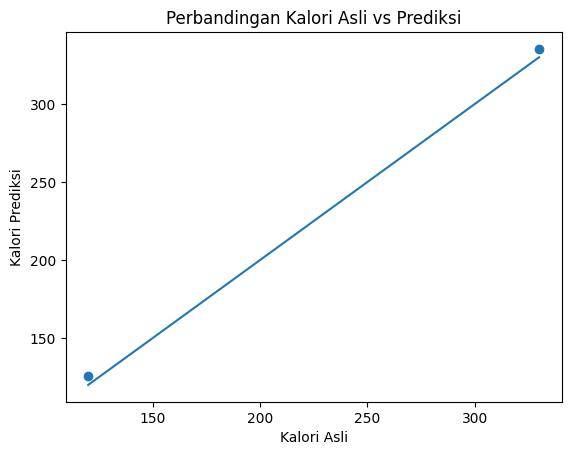

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

# Garis diagonal (prediksi sempurna)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Kalori Asli")
plt.ylabel("Kalori Prediksi")
plt.title("Perbandingan Kalori Asli vs Prediksi")

plt.show()

Grafik ini menunjukkan seberapa dekat hasil prediksi dengan nilai asli. Jika titik mendekati garis lurus, berarti model cukup baik.

**10. EVALUASI MODEL**

In [24]:
import numpy as np

print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 5.523809523809547
MSE: 30.54875283446737
RMSE: 5.527092620398845


Digunakan untuk mengukur error model. Semakin kecil nilainya, semakin akurat modelnya.

**11. PREDIKSI DATA BARU**

In [25]:
data_baru = [[60, 7, 70]]  # waktu, intensitas, berat badan
prediksi = model.predict(data_baru)

print("Prediksi kalori:", prediksi[0])

Prediksi kalori: 274.80000000000007


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Model digunakan untuk memprediksi kalori berdasarkan kondisi baru.

**12. PENGEMBANGAN**

In [26]:
print("\nPerbandingan Detail:")
for i in range(len(y_test)):
    print(f"Asli: {y_test.values[i]} | Prediksi: {y_pred[i]}")


Perbandingan Detail:
Asli: 330 | Prediksi: 335.33333333333337
Asli: 120 | Prediksi: 125.71428571428572


Kode ini digunakan untuk menampilkan perbandingan antara nilai kalori asli dengan hasil prediksi model secara lebih detail untuk setiap data testing. Dengan menggunakan perulangan (loop), setiap data akan ditampilkan satu per satu sehingga lebih mudah untuk melihat seberapa dekat hasil prediksi dengan nilai sebenarnya.

**ANALISIS**

Berdasarkan hasil praktikum, regresi linear berganda digunakan untuk memprediksi jumlah kalori terbakar berdasarkan waktu olahraga, intensitas, dan berat badan. Hasil prediksi yang diperoleh cukup mendekati nilai asli, yang menunjukkan bahwa model mampu bekerja dengan baik. Hal ini juga didukung oleh nilai error seperti MAE, MSE, dan RMSE yang relatif kecil, sehingga tingkat kesalahan prediksi masih dalam batas wajar. Dari visualisasi, terlihat bahwa sebagian besar data berada dekat dengan garis diagonal, yang menandakan bahwa hasil prediksi tidak jauh berbeda dari nilai sebenarnya. Secara keseluruhan, model regresi linear berganda cukup efektif karena dapat mempertimbangkan beberapa faktor sekaligus dalam melakukan prediksi.